In [3]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
# ============================================
# 2. LOAD DATASET
# ============================================

data = load_wine(as_frame=True)
df = data.frame

print("=" * 50)
print("WINE DATASET")
print("=" * 50)

print(f"Shape: {df.shape}")
print(f"Classes: {data.target_names}")
print(f"Features: {data.feature_names}")

print("\nFirst 5 rows:")
df.head()

WINE DATASET
Shape: (178, 14)
Classes: ['class_0' 'class_1' 'class_2']
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

First 5 rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [5]:
# Check data types and missing values

print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["target"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

In [6]:
# ============================================
# 3. SPLIT DATA
# ============================================

X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=" * 50)
print("DATA SPLIT")
print("=" * 50)

print(f"Training data: {X_train.shape[0]} rows")
print(f"Testing data: {X_test.shape[0]} rows")

DATA SPLIT
Training data: 142 rows
Testing data: 36 rows


In [7]:
# ============================================
# 4. SCALE FEATURES
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [8]:
# ============================================
# 5. LOGISTIC REGRESSION
# ============================================

logistic_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_reg.fit(X_train_scaled, y_train)

y_lg_predict = logistic_reg.predict(X_test_scaled)

lg_accuracy = accuracy_score(y_test, y_lg_predict)

print("=" * 50)
print("LOGISTIC REGRESSION")
print("=" * 50)

print(f"Accuracy: {lg_accuracy:.4f}")

LOGISTIC REGRESSION
Accuracy: 0.9722


In [9]:
# ============================================
# 6. RANDOM FOREST
# ============================================

forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Random Forest does not require feature scaling
forest.fit(X_train, y_train)

y_rf_predict = forest.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_rf_predict)

print("=" * 50)
print("RANDOM FOREST")
print("=" * 50)

print(f"Accuracy: {rf_accuracy:.4f}")

RANDOM FOREST
Accuracy: 1.0000


In [10]:
# Confusion Matrix

cm_rf = confusion_matrix(y_test, y_rf_predict)

print("Confusion Matrix:")
print(cm_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_rf_predict))

Confusion Matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [11]:
# ============================================
# 7. MODEL COMPARISON
# ============================================

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lg_accuracy,
        rf_accuracy
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.972222
1,Random Forest,1.000000


In [12]:
# ============================================
# 8. CROSS-VALIDATION
# ============================================

cv_scores = cross_val_score(
    forest,
    X_train,
    y_train,
    cv=5
)

print("=" * 50)
print("CROSS-VALIDATION - RANDOM FOREST")
print("=" * 50)

print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

CROSS-VALIDATION - RANDOM FOREST
Cross-validation scores: [1.         0.93103448 1.         1.         1.        ]
Mean CV Accuracy: 0.9862
Standard Deviation: 0.0276


In [13]:
# ============================================
# 9. HYPERPARAMETER TUNING
# ============================================

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

print("=" * 50)
print("HYPERPARAMETER TUNING")
print("=" * 50)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

HYPERPARAMETER TUNING
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score: 0.9862


In [14]:
# ============================================
# 10. FEATURE IMPORTANCE
# ============================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
9,color_intensity,0.187404
6,flavanoids,0.168373
12,proline,0.157024
0,alcohol,0.108171
10,hue,0.094966
11,od280/od315_of_diluted_wines,0.089898
5,total_phenols,0.051274
4,magnesium,0.035210
1,malic_acid,0.030246
8,proanthocyanins,0.028266


In [16]:
# ============================================
# LOGISTIC REGRESSION EVALUATION
# ============================================

cm_lg = confusion_matrix(y_test, y_lg_predict)

print("Confusion Matrix:")
print(cm_lg)

print("\nClassification Report:")
print(classification_report(y_test, y_lg_predict))

Confusion Matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



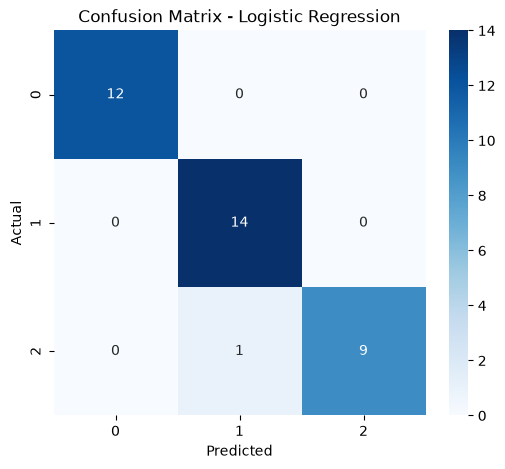

In [17]:
# ============================================
# 11a. LOGISTIC REGRESSION CONFUSION MATRIX
# ============================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lg,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

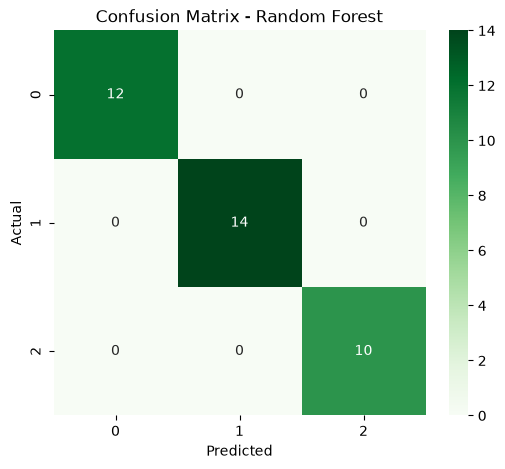

In [18]:
# ============================================
# 11b. RANDOM FOREST CONFUSION MATRIX
# ============================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

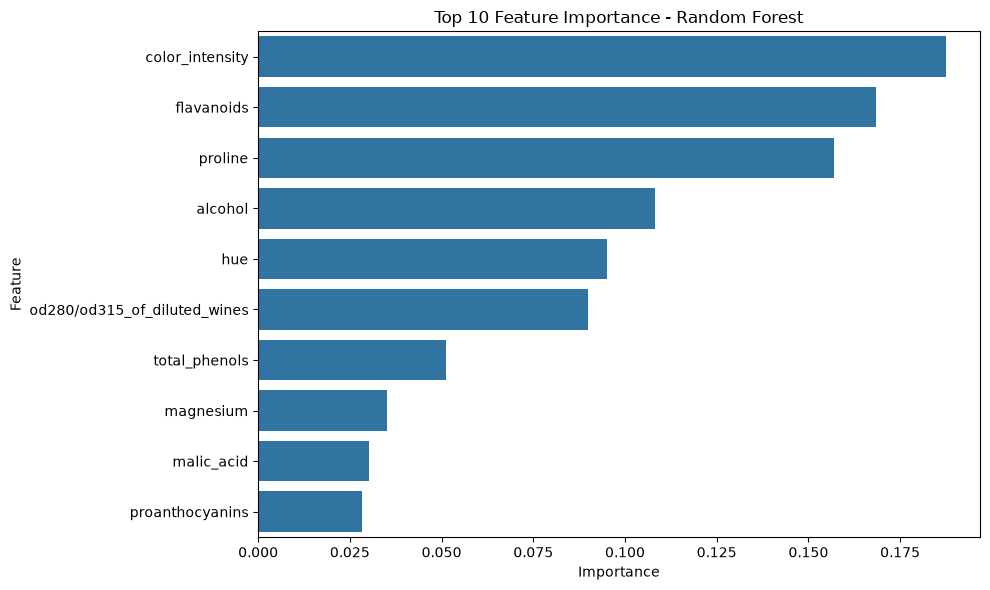

In [19]:
# ============================================
# 11c. FEATURE IMPORTANCE
# ============================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importance - Random Forest")
plt.tight_layout()

plt.show()

In [20]:
# ============================================
# 12. MISCLASSIFICATION ANALYSIS
# ============================================

misclassified = y_test != y_rf_predict

misclassified_indices = (
    misclassified[misclassified]
    .index
    .tolist()
)

print("=" * 50)
print("MISCLASSIFICATION ANALYSIS")
print("=" * 50)

print(f"Number of misclassified samples: {len(misclassified_indices)}")
print(f"Misclassified indices: {misclassified_indices}")

if len(misclassified_indices) > 0:

    print("\nMisclassified samples:")

    for idx in misclassified_indices[:5]:
        actual = y_test.loc[idx]
        predicted = y_rf_predict[list(y_test.index).index(idx)]

        print(
            f"Index {idx}: "
            f"Actual={actual}, "
            f"Predicted={predicted}"
        )

MISCLASSIFICATION ANALYSIS
Number of misclassified samples: 0
Misclassified indices: []


In [21]:
# ============================================
# 13. SUMMARY
# ============================================

print("=" * 50)
print("FINAL SUMMARY")
print("=" * 50)

print(f"Logistic Regression Accuracy: {lg_accuracy:.4f}")
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

best_model = (
    "Random Forest"
    if rf_accuracy > lg_accuracy
    else "Logistic Regression"
)

print(f"Best Model: {best_model}")

print(f"Best Hyperparameters: {grid_search.best_params_}")

print(f"Cross-Validation Mean: {cv_scores.mean():.4f}")

FINAL SUMMARY
Logistic Regression Accuracy: 0.9722
Random Forest Accuracy: 1.0000
Best Model: Random Forest
Best Hyperparameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Cross-Validation Mean: 0.9862
